In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from ates import evaluate
from ates.models import autoatesv2, simple
from ates.validate import Validator

# Validate MRDEM Tiles

CDEM is outdated and HRDEM is incomplete so the Medium Resolution DEM is used. It has a similar precision ~25m but was scanned between 2010-2013. 


In [2]:
validation_dir = Path.cwd().parent / "data" / "validation"

## Mount Seymour

In [3]:
mount_seymour_kmz = validation_dir / "mount-seymour" / "layers.kmz"
v_mrdem = Validator(mount_seymour_kmz, simple, dem_source="mrdem").run()
v_cdem  = Validator(mount_seymour_kmz, simple, dem_source="cdem").run()


In [4]:
evaluate.report(v_mrdem.predicted, v_mrdem.truth, save_dir=mount_seymour_kmz.parent)

In [5]:
evaluate.report(v_cdem.predicted, v_cdem.truth, save_dir=mount_seymour_kmz.parent)

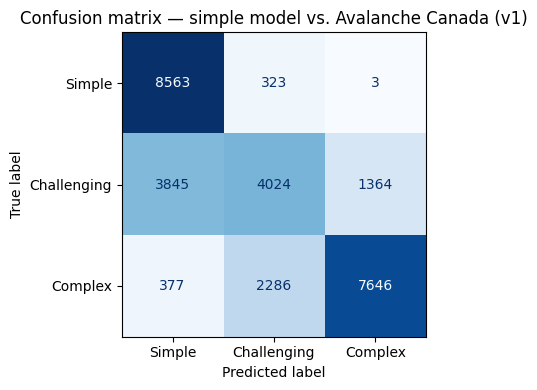

In [6]:
evaluate.plot_confusion_matrix(v_cdem.predicted, v_cdem.truth)

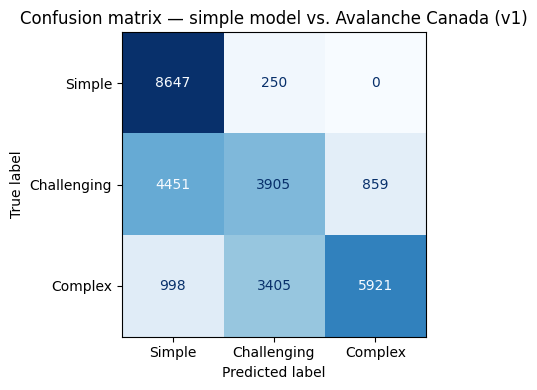

In [9]:
evaluate.plot_confusion_matrix(v_mrdem.predicted, v_mrdem.truth)

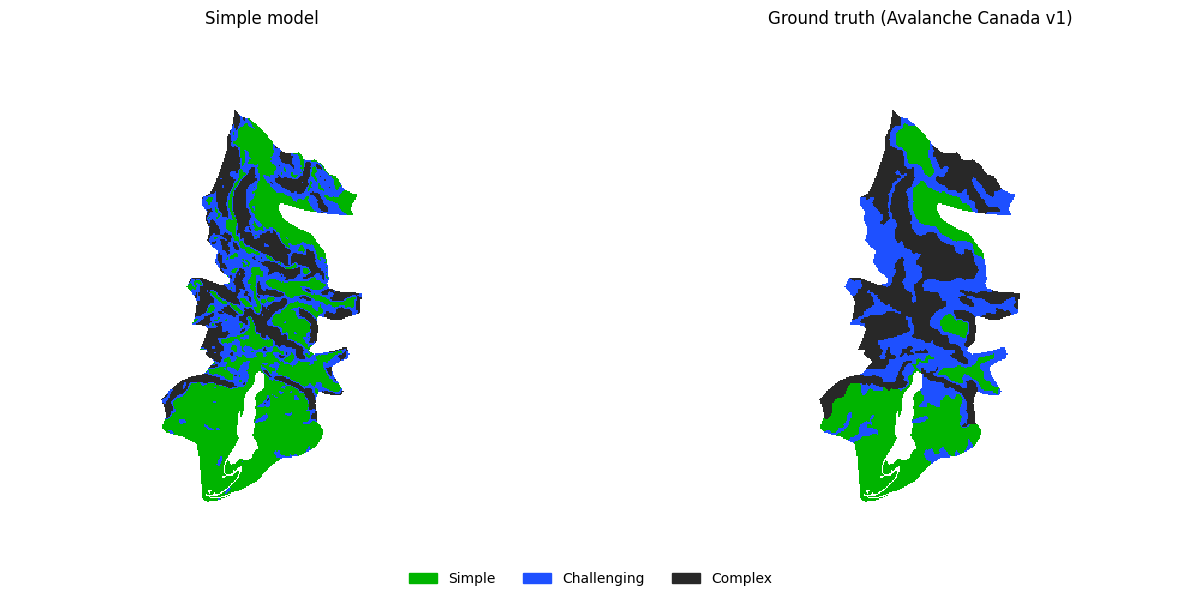

In [11]:
evaluate.plot_side_by_side(v_mrdem.predicted, v_mrdem.truth, predicted_title="Simple model")

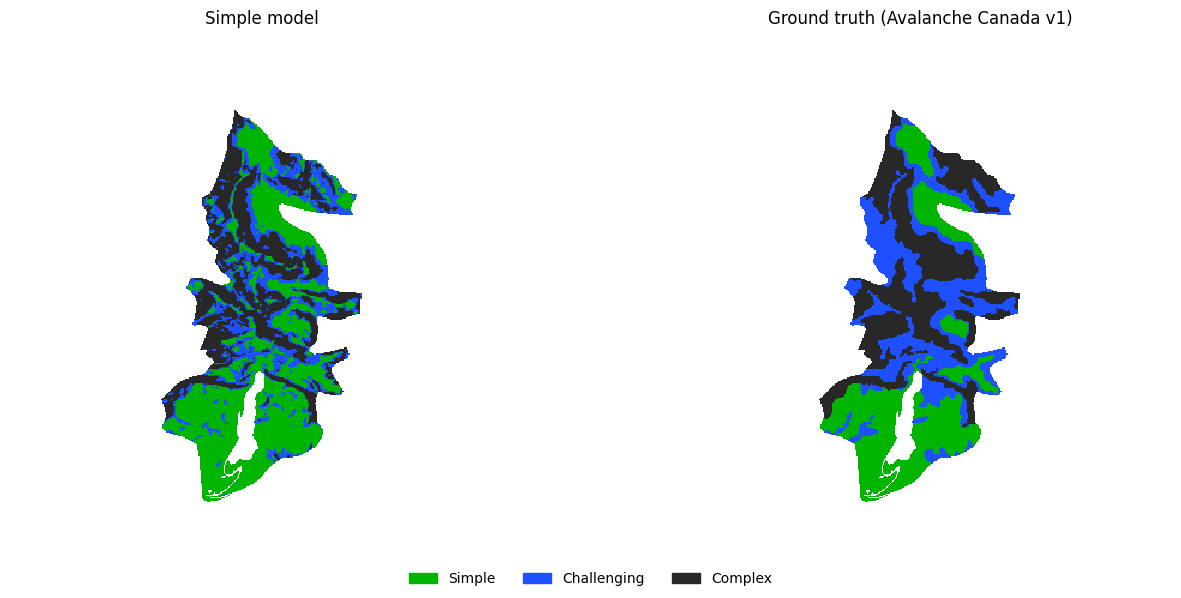

In [13]:
evaluate.plot_side_by_side(v_cdem.predicted, v_cdem.truth, predicted_title="Simple model")

## Conclusion
Seems like CDEM is more performant in higher consequence terrain (Complex). The biggest loser seems to be Challenging. 